# MedGemma AI Triage System - Performance Evaluation

This notebook evaluates the performance of the triage system on test scenarios and generates metrics.

In [1]:
import sys
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Add src to path
sys.path.insert(0, str(Path.cwd().parent))

from src.workflows.triage_workflow import TriageWorkflow
from src.utils.logger import logger

sns.set_style('whitegrid')
%matplotlib inline

print("✓ Imports successful")

✓ Imports successful


## Load Test Scenarios

Load the predefined test scenarios from the data directory.

In [2]:
# Load test scenarios
scenarios_file = Path.cwd().parent / "data" / "test_scenarios.json"

with open(scenarios_file, 'r') as f:
    data = json.load(f)

scenarios = data["test_scenarios"]
print(f"Loaded {len(scenarios)} test scenarios")

# Display scenario distribution
df_scenarios = pd.DataFrame(scenarios)
print("\nScenario Distribution:")
print(df_scenarios['category'].value_counts())

Loaded 14 test scenarios

Scenario Distribution:
category
EMERGENCY      3
URGENT         3
SEMI-URGENT    3
NON-URGENT     3
EDGE_CASE      2
Name: count, dtype: int64


## Initialize Triage System

Initialize the workflow (this may take a few minutes to load the model).

In [3]:
# Initialize workflow (this may take a few minutes)
print("Initializing triage workflow...")
workflow = TriageWorkflow()
print("✓ Workflow ready!")

2026-01-21 16:19:12 | INFO     | src.workflows.triage_workflow:__init__ - Initializing TriageWorkflow
2026-01-21 16:19:12 | INFO     | src.workflows.agent_coordinator:__init__ - AgentCoordinator initialized
2026-01-21 16:19:12 | INFO     | src.models.medgemma_client:__init__ - Initializing MedGemmaClient with model: google/medgemma-1.5-4b-it
2026-01-21 16:19:12 | INFO     | src.models.medgemma_client:__init__ - Device: cpu
2026-01-21 16:19:12 | INFO     | src.models.medgemma_client:load_model - Logging in to Hugging Face...
Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.
2026-01-21 16:19:12 | INFO     | src.models.medgemma_client:load_model - Loading tokenizer from google/medgemma-1.5-4b-it...


Initializing triage workflow...


2026-01-21 16:19:13 | INFO     | src.models.medgemma_client:load_model - Loading model from google/medgemma-1.5-4b-it...
`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

2026-01-21 16:19:42 | SUCCESS  | src.models.medgemma_client:load_model - Model loaded successfully on cpu
2026-01-21 16:19:42 | INFO     | src.agents.base_agent:__init__ - Initialized Intake Agent
2026-01-21 16:19:42 | INFO     | src.agents.base_agent:__init__ - Initialized Symptom Assessment Agent
2026-01-21 16:19:42 | INFO     | src.agents.base_agent:__init__ - Initialized Medical Knowledge Agent
2026-01-21 16:19:42 | INFO     | src.agents.base_agent:__init__ - Initialized Urgency Classification Agent
2026-01-21 16:19:42 | INFO     | src.agents.base_agent:__init__ - Initialized Care Recommendation Agent
2026-01-21 16:19:42 | INFO     | src.agents.base_agent:__init__ - Initialized Communication Agent
2026-01-21 16:19:42 | SUCCESS  | src.workflows.triage_workflow:__init__ - All agents initialized successfully


✓ Workflow ready!


## Run Evaluation

Run triage on all test scenarios and collect results.

In [4]:
# Run triage on all scenarios
results = []

# Scenario-specific follow-up templates
FOLLOWUP_BY_CATEGORY = {
    "EMERGENCY": (
        "Symptoms started suddenly within the last hour. Severity 9/10. "
        "Pain/shortness of breath is constant and worsening. "
        "Associated symptoms: sweating, nausea, dizziness. "
        "No known chronic conditions. Not on medications."
    ),
    "URGENT": (
        "Symptoms started 1-2 days ago and are moderate to severe (7/10). "
        "Constant symptoms with some worsening. "
        "Associated symptoms: fever or significant pain. "
        "No major medical history. Not on medications."
    ),
    "SEMI-URGENT": (
        "Symptoms started 2-3 days ago and are moderate (5/10). "
        "Symptoms are persistent but stable. "
        "No severe red flags like chest pain or severe shortness of breath. "
        "No significant medical history. Not on medications."
    ),
    "NON-URGENT": (
        "Symptoms started yesterday and are mild (2-3/10). "
        "Symptoms come and go. No fever. No chest pain or shortness of breath. "
        "No medical history. Not on medications."
    ),
    "EDGE_CASE": (
        "Symptoms are vague and have been present for a few days. Severity 4/10. "
        "No red flags like chest pain, severe bleeding, or trouble breathing. "
        "No major medical history. Not on medications."
    ),
}

for i, scenario in enumerate(scenarios, 1):
    print(f"[{i}/{len(scenarios)}] Testing: {scenario['id']}")
    
    try:
        result = workflow.start_triage(scenario['patient_input'])
        
        # If intake asks follow-ups, provide scenario-specific answers
        attempts = 0
        while result.get('needs_more_info') and attempts < 2:
            followup_answer = FOLLOWUP_BY_CATEGORY.get(
                scenario['category'],
                "Symptoms started 2 days ago. Severity 5/10. No major medical history."
            )
            result = workflow.continue_intake(result['session_id'], followup_answer)
            attempts += 1
        
        needs_more_info = result.get('needs_more_info', False)
        actual_urgency = result.get('urgency_level', '')
        success = (not result.get('error')) and (not needs_more_info) and bool(actual_urgency)
        
        results.append({
            'scenario_id': scenario['id'],
            'category': scenario['category'],
            'expected_urgency': scenario['expected_urgency'],
            'actual_urgency': actual_urgency,
            'correct': actual_urgency == scenario['expected_urgency'],
            'time_sensitive': result.get('time_sensitive', False),
            'red_flags': len(result.get('red_flags', [])),
            'care_setting': result.get('care_setting', ''),
            'needs_more_info': needs_more_info,
            'success': success,
            'error': result.get('error', '')
        })
    except Exception as e:
        print(f"  Error: {e}")
        results.append({
            'scenario_id': scenario['id'],
            'category': scenario['category'],
            'success': False,
            'needs_more_info': False,
            'error': str(e)
        })

df_results = pd.DataFrame(results)
print("\n✓ Evaluation complete!")

2026-01-21 16:19:42 | INFO     | src.workflows.agent_coordinator:create_session - Created session: a2e491ca-545f-42fb-9777-225b797a689d
2026-01-21 16:19:42 | INFO     | src.workflows.triage_workflow:start_triage - Starting triage session a2e491ca-545f-42fb-9777-225b797a689d
2026-01-21 16:19:42 | INFO     | src.agents.intake_agent:process - Intake Agent processing initial input
`generation_config` default values have been modified to match model-specific defaults: {'top_k': 64}. If this is not desired, please set these values explicitly.


[1/14] Testing: emergency_001


2026-01-21 16:38:40 | INFO     | src.agents.intake_agent:_generate_case_summary - Intake Agent generated case summary
2026-01-21 16:38:40 | INFO     | src.workflows.triage_workflow:_run_full_triage - Running full triage for session a2e491ca-545f-42fb-9777-225b797a689d
2026-01-21 16:38:40 | INFO     | src.workflows.agent_coordinator:update_session_state - Session a2e491ca-545f-42fb-9777-225b797a689d state: intake -> symptom_assessment
2026-01-21 16:38:40 | INFO     | src.workflows.triage_workflow:_run_full_triage - Session a2e491ca-545f-42fb-9777-225b797a689d: Symptom Assessment
2026-01-21 16:38:40 | INFO     | src.agents.symptom_agent:process - Symptom Assessment Agent analyzing symptoms
2026-01-21 16:54:34 | INFO     | src.agents.symptom_agent:process - Symptom Assessment Agent identified 10 primary symptoms
2026-01-21 16:54:34 | WARNING  | src.agents.symptom_agent:process - Symptom Assessment Agent detected red flags: [{'flag': 'severe chest pain', 'severity': 'critical', 'context': 

[2/14] Testing: emergency_002


2026-01-21 17:30:49 | INFO     | src.agents.intake_agent:_generate_case_summary - Intake Agent generated case summary
2026-01-21 17:30:49 | INFO     | src.workflows.triage_workflow:_run_full_triage - Running full triage for session 37ffbe9f-d090-40de-bc28-11c729e8e3e8
2026-01-21 17:30:49 | INFO     | src.workflows.agent_coordinator:update_session_state - Session 37ffbe9f-d090-40de-bc28-11c729e8e3e8 state: intake -> symptom_assessment
2026-01-21 17:30:49 | INFO     | src.workflows.triage_workflow:_run_full_triage - Session 37ffbe9f-d090-40de-bc28-11c729e8e3e8: Symptom Assessment
2026-01-21 17:30:49 | INFO     | src.agents.symptom_agent:process - Symptom Assessment Agent analyzing symptoms
2026-01-21 17:49:00 | INFO     | src.agents.symptom_agent:process - Symptom Assessment Agent identified 10 primary symptoms
2026-01-21 17:49:01 | WARNING  | src.agents.symptom_agent:process - Symptom Assessment Agent detected red flags: [{'flag': 'severe difficulty breathing', 'severity': 'critical', '

...

[13/14] Testing: edge_case_001


2026-01-22 04:27:32 | INFO     | src.workflows.triage_workflow:start_triage - Session 01e67487-dac1-4292-808e-9d5967cdb24d needs more information
2026-01-22 04:27:32 | INFO     | src.workflows.triage_workflow:continue_intake - Continuing intake for session 01e67487-dac1-4292-808e-9d5967cdb24d
2026-01-22 04:27:32 | INFO     | src.agents.intake_agent:process - Intake Agent processing follow-up input
2026-01-22 04:44:12 | INFO     | src.agents.intake_agent:_generate_case_summary - Intake Agent generated case summary
2026-01-22 04:44:12 | INFO     | src.workflows.triage_workflow:_run_full_triage - Running full triage for session 01e67487-dac1-4292-808e-9d5967cdb24d
2026-01-22 04:44:12 | INFO     | src.workflows.agent_coordinator:update_session_state - Session 01e67487-dac1-4292-808e-9d5967cdb24d state: intake -> symptom_assessment
2026-01-22 04:44:12 | INFO     | src.workflows.triage_workflow:_run_full_triage - Session 01e67487-dac1-4292-808e-9d5967cdb24d: Symptom Assessment
2026-01-22 04:

[14/14] Testing: edge_case_002


2026-01-22 05:37:58 | INFO     | src.agents.intake_agent:_generate_case_summary - Intake Agent generated case summary
2026-01-22 05:37:58 | INFO     | src.workflows.triage_workflow:_run_full_triage - Running full triage for session 6f3c146a-733c-416d-ae5d-73441169fb00
2026-01-22 05:37:58 | INFO     | src.workflows.agent_coordinator:update_session_state - Session 6f3c146a-733c-416d-ae5d-73441169fb00 state: intake -> symptom_assessment
2026-01-22 05:37:58 | INFO     | src.workflows.triage_workflow:_run_full_triage - Session 6f3c146a-733c-416d-ae5d-73441169fb00: Symptom Assessment
2026-01-22 05:37:58 | INFO     | src.agents.symptom_agent:process - Symptom Assessment Agent analyzing symptoms
2026-01-22 05:55:29 | INFO     | src.agents.symptom_agent:process - Symptom Assessment Agent identified 10 primary symptoms
2026-01-22 05:55:29 | INFO     | src.workflows.agent_coordinator:update_session_state - Session 6f3c146a-733c-416d-ae5d-73441169fb00 state: symptom_assessment -> urgency_classific


✓ Evaluation complete!


## Performance Metrics

Calculate overall accuracy and per-category performance.

In [5]:
# Overall accuracy
successful = df_results[df_results['success'] == True]
accuracy = successful['correct'].mean() if len(successful) > 0 else 0

print(f"Overall Accuracy: {accuracy:.2%}")
print(f"Successful Runs: {len(successful)}/{len(df_results)}")

# Intake follow-up stats
if 'needs_more_info' in df_results.columns:
    followups = df_results[df_results['needs_more_info'] == True]
    print(f"Needs-more-info Runs: {len(followups)}/{len(df_results)}")

# Accuracy by category
print("\nAccuracy by Category:")
if len(successful) > 0:
    category_acc = successful.groupby('category')['correct'].agg(['mean', 'count'])
    category_acc.columns = ['Accuracy', 'Count']
    category_acc['Accuracy'] = category_acc['Accuracy'].apply(lambda x: f"{x:.2%}")
    print(category_acc)
else:
    print("No successful runs to analyze")

Overall Accuracy: 85.71%
Successful Runs: 14/14
Needs-more-info Runs: 0/14

Accuracy by Category:
            Accuracy  Count
category                   
EDGE_CASE    100.00%      2
EMERGENCY    100.00%      3
NON-URGENT    66.67%      3
SEMI-URGENT   66.67%      3
URGENT       100.00%      3


## Confusion Matrix

Visualize prediction accuracy across urgency levels.

Classification Report:
              precision    recall  f1-score   support

   EMERGENCY       1.00      1.00      1.00         3
  NON-URGENT       0.67      0.67      0.67         3
 SEMI-URGENT       0.80      0.80      0.80         5
      URGENT       1.00      1.00      1.00         3

    accuracy                           0.86        14
   macro avg       0.87      0.87      0.87        14
weighted avg       0.86      0.86      0.86        14



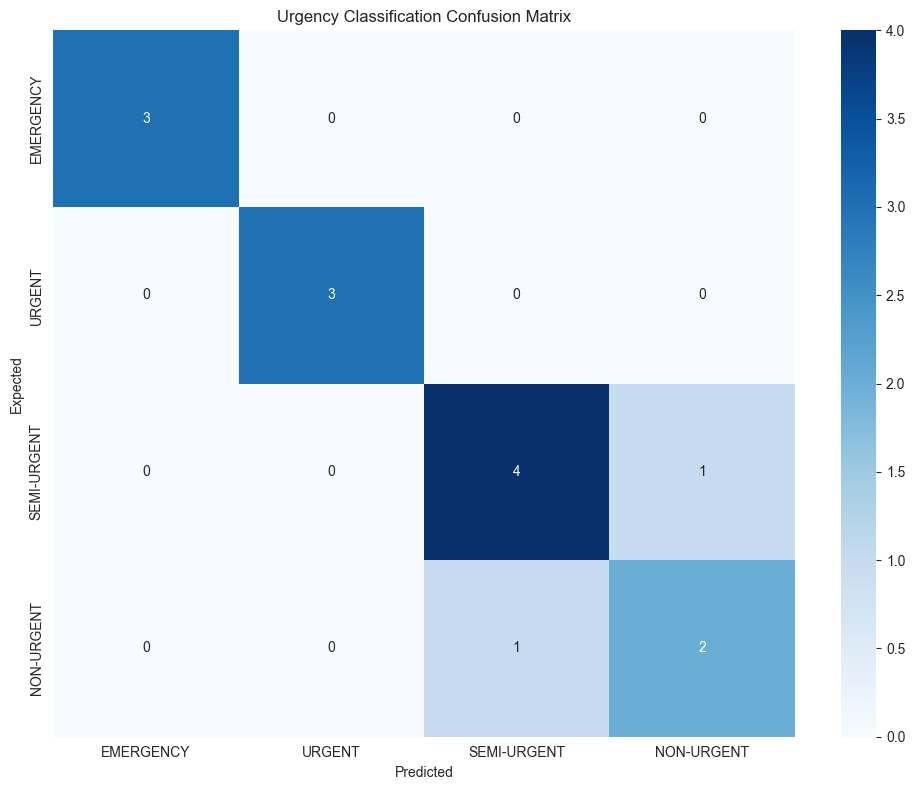

In [6]:
if len(successful) > 0:
    from sklearn.metrics import confusion_matrix, classification_report
    
    y_true = successful['expected_urgency']
    y_pred = successful['actual_urgency']
    
    if y_pred.isnull().all() or (y_pred == '').all():
        print("No valid predictions to visualize (all empty).")
    else:
        print("Classification Report:")
        print(classification_report(y_true, y_pred))
        
        # Plot confusion matrix
        labels = ['EMERGENCY', 'URGENT', 'SEMI-URGENT', 'NON-URGENT']
        cm = confusion_matrix(y_true, y_pred, labels=labels)
        
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=labels,
                    yticklabels=labels)
        plt.title('Urgency Classification Confusion Matrix')
        plt.ylabel('Expected')
        plt.xlabel('Predicted')
        plt.tight_layout()
        plt.show()
else:
    print("No successful runs to visualize")

## Red Flag Detection Analysis

Evaluate the system's ability to detect emergency symptoms.

In [7]:
# Red flag detection analysis
if len(successful) > 0:
    emergency_cases = successful[successful['expected_urgency'] == 'EMERGENCY']
    
    if len(emergency_cases) > 0:
        print(f"Emergency Cases: {len(emergency_cases)}")
        print(f"Cases with Red Flags Detected: {(emergency_cases['red_flags'] > 0).sum()}")
        print(f"Red Flag Detection Rate: {(emergency_cases['red_flags'] > 0).mean():.2%}")
    else:
        print("No emergency cases in test set")
else:
    print("No successful runs to analyze")

Emergency Cases: 3
Cases with Red Flags Detected: 3
Red Flag Detection Rate: 100.00%


## Visualizations

Create charts showing accuracy by category and test distribution.

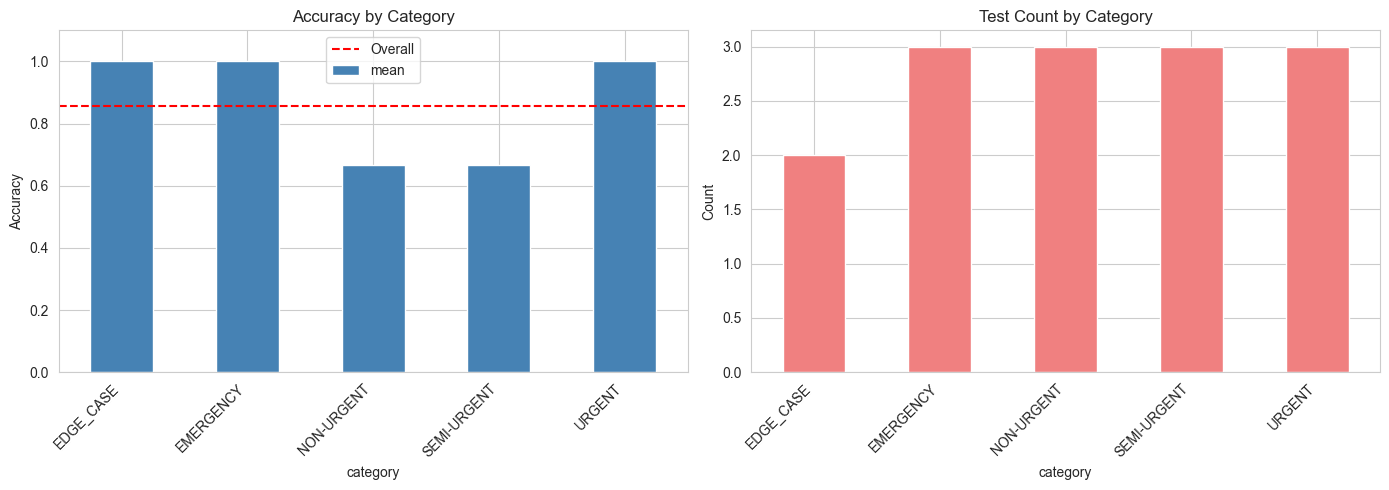

In [8]:
# Accuracy by category bar chart
if len(successful) > 0:
    category_stats = successful.groupby('category')['correct'].agg(['mean', 'count'])
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Accuracy by category
    category_stats['mean'].plot(kind='bar', ax=ax1, color='steelblue')
    ax1.set_title('Accuracy by Category')
    ax1.set_ylabel('Accuracy')
    ax1.set_ylim([0, 1.1])
    ax1.axhline(y=accuracy, color='r', linestyle='--', label='Overall')
    ax1.legend()
    ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
    
    # Test count by category
    category_stats['count'].plot(kind='bar', ax=ax2, color='lightcoral')
    ax2.set_title('Test Count by Category')
    ax2.set_ylabel('Count')
    ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()
else:
    print("No successful runs to visualize")

## Export Results

Save evaluation results to CSV and JSON for further analysis.

In [9]:
# Save results
results_file = Path.cwd().parent / "data" / "evaluation_results.csv"
df_results.to_csv(results_file, index=False)
print(f"Results saved to: {results_file}")

# Save summary
if len(successful) > 0:
    summary = {
        'total_tests': len(df_results),
        'successful_runs': len(successful),
        'overall_accuracy': float(accuracy),
        'emergency_accuracy': float(successful[successful['expected_urgency'] == 'EMERGENCY']['correct'].mean()) if len(successful[successful['expected_urgency'] == 'EMERGENCY']) > 0 else 0,
        'urgent_accuracy': float(successful[successful['expected_urgency'] == 'URGENT']['correct'].mean()) if len(successful[successful['expected_urgency'] == 'URGENT']) > 0 else 0,
        'semi_urgent_accuracy': float(successful[successful['expected_urgency'] == 'SEMI-URGENT']['correct'].mean()) if len(successful[successful['expected_urgency'] == 'SEMI-URGENT']) > 0 else 0,
        'non_urgent_accuracy': float(successful[successful['expected_urgency'] == 'NON-URGENT']['correct'].mean()) if len(successful[successful['expected_urgency'] == 'NON-URGENT']) > 0 else 0
    }
    
    summary_file = Path.cwd().parent / "data" / "evaluation_summary.json"
    with open(summary_file, 'w') as f:
        json.dump(summary, f, indent=2)
    print(f"Summary saved to: {summary_file}")
    
    print("\n=== Final Summary ===")
    print(json.dumps(summary, indent=2))
else:
    print("No successful runs to save")

Results saved to: /Users/shenry/Documents/Personal/Training/Project/Kaggle/MedGemma Impact Challenge/data/evaluation_results.csv
Summary saved to: /Users/shenry/Documents/Personal/Training/Project/Kaggle/MedGemma Impact Challenge/data/evaluation_summary.json

=== Final Summary ===
{
  "total_tests": 14,
  "successful_runs": 14,
  "overall_accuracy": 0.8571428571428571,
  "emergency_accuracy": 1.0,
  "urgent_accuracy": 1.0,
  "semi_urgent_accuracy": 0.8,
  "non_urgent_accuracy": 0.6666666666666666
}


## Detailed Results Review

Display detailed results for each test case.

In [10]:
# Display detailed results table
print("Detailed Results:")
if len(df_results) > 0:
    display_cols = ['scenario_id', 'category', 'expected_urgency', 'actual_urgency', 'correct', 'success']
    display_df = df_results[display_cols] if all(col in df_results.columns for col in display_cols) else df_results
    print(display_df.to_string())
else:
    print("No results to display")

Detailed Results:
        scenario_id     category expected_urgency actual_urgency  correct  success
0     emergency_001    EMERGENCY        EMERGENCY      EMERGENCY     True     True
1     emergency_002    EMERGENCY        EMERGENCY      EMERGENCY     True     True
2     emergency_003    EMERGENCY        EMERGENCY      EMERGENCY     True     True
3        urgent_001       URGENT           URGENT         URGENT     True     True
4        urgent_002       URGENT           URGENT         URGENT     True     True
5        urgent_003       URGENT           URGENT         URGENT     True     True
6   semi_urgent_001  SEMI-URGENT      SEMI-URGENT     NON-URGENT    False     True
7   semi_urgent_002  SEMI-URGENT      SEMI-URGENT    SEMI-URGENT     True     True
8   semi_urgent_003  SEMI-URGENT      SEMI-URGENT    SEMI-URGENT     True     True
9    non_urgent_001   NON-URGENT       NON-URGENT    SEMI-URGENT    False     True
10   non_urgent_002   NON-URGENT       NON-URGENT     NON-URGENT     